# 6.1 — Superfícies de Resposta: ET e M_CH3OH em função de (BRC1, RFF)

Grade 200×200 sobre os dois inputs de maior importância aditiva para ET e M_CH3OH (Etapa 4):  
- **RFF** — S₁ = 0.437 para ET (maior índice de Sobol de primeira ordem)  
- **BRC1** — S₁ = 0.318 para ET (segundo maior)

Os demais 4 inputs do conjunto S₆ = {T1, RRC1, BRC1, RRC2, BRC2, RFF} são fixados na média da faixa física (D-E6-02).  
Nenhum modelo novo é treinado — toda computação é avaliação do surrogate SVR k*=6 serializado na Etapa 3.

## Seção 1 — Imports e Carga dos Modelos

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

BASE_E3  = "../../ETAPA_3/3.3_REDUZIDO/SVR"
BASE_E0  = "../../ETAPA_0/processed"
BASE_OUT = "."  # ARTEFATOS/ETAPA_6/6.1/

# Modelos SVR k*=6
model_ET = joblib.load(f"{BASE_E3}/ET/k6/model.pkl")
model_M  = joblib.load(f"{BASE_E3}/M_CH3OH/k6/model.pkl")

# Scalers de X (8 features originais)
scaler_min   = np.load(f"{BASE_E0}/scaler_X_min.npy")    # shape (8,)
scaler_scale = np.load(f"{BASE_E0}/scaler_X_scale.npy")  # shape (8,)

# Scalers de y — ordem das colunas: [M_CH3OH, x_CH3OH, ET]
scaler_y_min   = np.load(f"{BASE_E0}/scaler_y_min.npy")    # shape (3,)
scaler_y_scale = np.load(f"{BASE_E0}/scaler_y_scale.npy")  # shape (3,)

# Índices de S_6 no vetor de 8 features: [T1, RRC1, BRC1, RRC2, BRC2, RFF]
# Colunas em X: ['P1', 'T1', 'T2', 'RRC1', 'BRC1', 'RRC2', 'BRC2', 'RFF']
#                  0     1    2      3       4       5       6       7
S6_IDX = [1, 3, 4, 5, 6, 7]  # T1, RRC1, BRC1, RRC2, BRC2, RFF

scaler_min_S6   = scaler_min[S6_IDX]
scaler_scale_S6 = scaler_scale[S6_IDX]

# Dataset de teste — overlay nos mapas de contorno (valores físicos)
# X_test.csv contém valores normalizados; usar X_test_raw.npy (espaço físico)
# Colunas raw: [P1, T1, T2, RRC1, BRC1, RRC2, BRC2, RFF] — índices 4=BRC1, 7=RFF
X_test_raw = np.load(f"{BASE_E0}/X_test_raw.npy")  # shape (193, 8)
RFF_test   = X_test_raw[:, 7]
BRC1_test  = X_test_raw[:, 4]

print("Modelos carregados:", type(model_ET).__name__, type(model_M).__name__)
print("scaler_min_S6  :", scaler_min_S6)
print("scaler_scale_S6:", scaler_scale_S6)
print("scaler_y_min   :", scaler_y_min)
print("scaler_y_scale :", scaler_y_scale)
print("X_test_raw shape:", X_test_raw.shape)


## Seção 2 — Definição da Grade 200×200

In [2]:
# Faixas físicas dos inputs varridos
rff_grid  = np.linspace(0.01, 0.25, 200)
brc1_grid = np.linspace(0.5,  10.0, 200)

# Meshgrid — convenção: RFF no eixo x (colunas), BRC1 no eixo y (linhas)
RFF_mesh, BRC1_mesh = np.meshgrid(rff_grid, brc1_grid)  # shape (200, 200) cada

# Valores fixos (média da faixa física) para os outros 4 inputs de S_6
# Ordem S_6: [T1, RRC1, BRC1, RRC2, BRC2, RFF]
T1_fixed   = (200 + 300) / 2   # = 250.0 °C
RRC1_fixed = (1   + 10 ) / 2   # =   5.5
RRC2_fixed = (1   + 10 ) / 2   # =   5.5
BRC2_fixed = (0.5 + 10 ) / 2   # =   5.25

N = 200 * 200  # = 40.000 pontos

X_grid = np.column_stack([
    np.full(N, T1_fixed),    # T1
    np.full(N, RRC1_fixed),  # RRC1
    BRC1_mesh.ravel(),       # BRC1
    np.full(N, RRC2_fixed),  # RRC2
    np.full(N, BRC2_fixed),  # BRC2
    RFF_mesh.ravel(),        # RFF
])  # shape (40000, 6)

# Normalização min-max com escalares de S_6
X_grid_norm = (X_grid - scaler_min_S6) / scaler_scale_S6

print(f"Grade: {X_grid.shape} | Normalizada: {X_grid_norm.shape}")
print(f"Inputs fixos — T1={T1_fixed}, RRC1={RRC1_fixed}, RRC2={RRC2_fixed}, BRC2={BRC2_fixed}")

Grade: (40000, 6) | Normalizada: (40000, 6)
Inputs fixos — T1=250.0, RRC1=5.5, RRC2=5.5, BRC2=5.25


## Seção 3 — Predição do Surrogate

In [3]:
# Predição em espaço normalizado — modelos foram treinados com y normalizado
ET_norm = model_ET.predict(X_grid_norm).reshape(200, 200)
M_norm  = model_M.predict(X_grid_norm).reshape(200, 200)

# Desnormalização para unidades físicas
# Ordem de y: [M_CH3OH=0, x_CH3OH=1, ET=2]
ET_pred = ET_norm * scaler_y_scale[2] + scaler_y_min[2]  # kW
M_pred  = M_norm  * scaler_y_scale[0] + scaler_y_min[0]  # kg/hr

print("ET  (kW)    — min:", ET_pred.min().round(0), "| max:", ET_pred.max().round(0), "| NaN:", np.isnan(ET_pred).sum())
print("M   (kg/hr) — min:", M_pred.min().round(1),  "| max:", M_pred.max().round(1),  "| NaN:", np.isnan(M_pred).sum())


ET  (kW)    — min: 8147.0 | max: 83525.0 | NaN: 0
M   (kg/hr) — min: 1802.3 | max: 13098.3 | NaN: 0


## Seção 4 — Visualizações

### 4.1 — Superfície 3D: ET

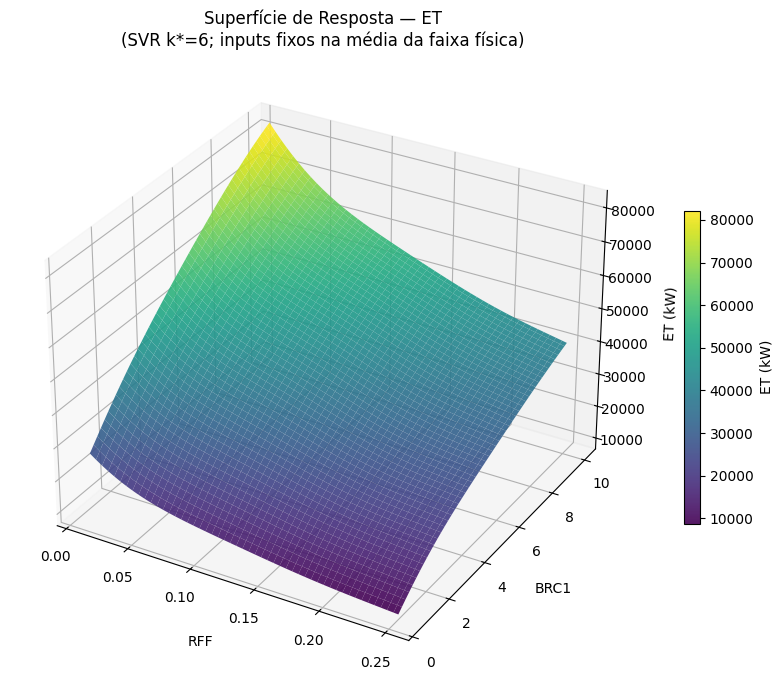

Salvo: 6.1_sr_ET_M_BRC1_RFF_3d.png


In [4]:
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    RFF_mesh, BRC1_mesh, ET_pred,
    cmap='viridis', linewidth=0, antialiased=True, alpha=0.9
)
fig.colorbar(surf, ax=ax, shrink=0.5, label='ET (kW)')

ax.set_xlabel('RFF', labelpad=10)
ax.set_ylabel('BRC1', labelpad=10)
ax.set_zlabel('ET (kW)', labelpad=10)
ax.set_title('Superfície de Resposta — ET\n(SVR k*=6; inputs fixos na média da faixa física)')

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/6.1_sr_ET_M_BRC1_RFF_3d.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: 6.1_sr_ET_M_BRC1_RFF_3d.png")

### 4.2 — Mapa de Contorno: ET (com overlay do dataset original)

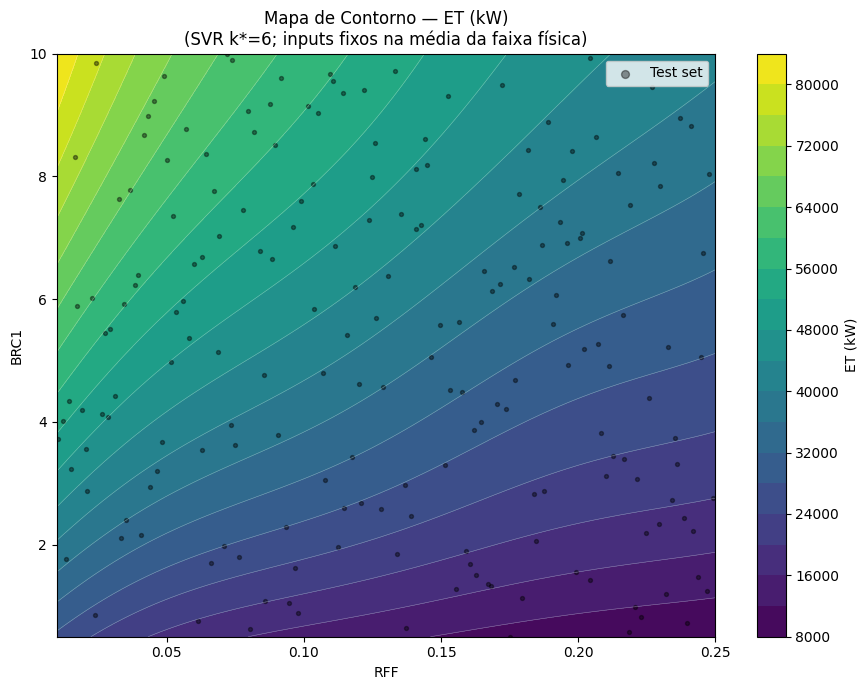

Salvo: 6.1_sr_ET_M_BRC1_RFF_contorno.png


In [5]:
fig, ax = plt.subplots(figsize=(9, 7))

cf = ax.contourf(RFF_mesh, BRC1_mesh, ET_pred, levels=20, cmap='viridis')
fig.colorbar(cf, ax=ax, label='ET (kW)')
ax.contour(RFF_mesh, BRC1_mesh, ET_pred, levels=20, colors='white', linewidths=0.4, alpha=0.4)

ax.scatter(RFF_test, BRC1_test, c='black', s=8, alpha=0.4, label='Test set')

ax.set_xlabel('RFF')
ax.set_ylabel('BRC1')
ax.set_title('Mapa de Contorno — ET (kW)\n(SVR k*=6; inputs fixos na média da faixa física)')
ax.legend(loc='upper right', markerscale=2)

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/6.1_sr_ET_M_BRC1_RFF_contorno.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: 6.1_sr_ET_M_BRC1_RFF_contorno.png")


### 4.3 — Superfície 3D: M_CH3OH

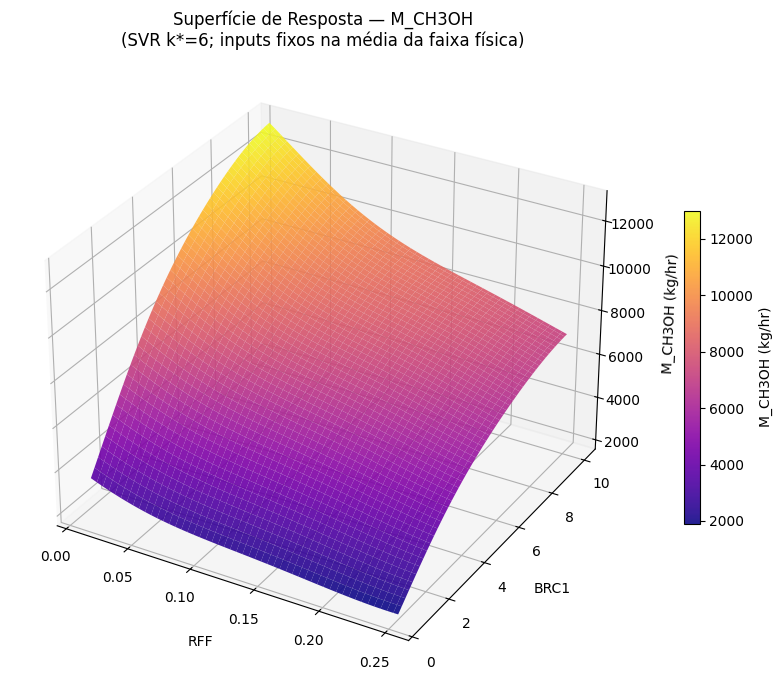

Salvo: 6.1_sr_M_BRC1_RFF_3d.png


In [6]:
fig = plt.figure(figsize=(10, 7))
ax  = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(
    RFF_mesh, BRC1_mesh, M_pred,
    cmap='plasma', linewidth=0, antialiased=True, alpha=0.9
)
fig.colorbar(surf, ax=ax, shrink=0.5, label='M_CH3OH (kg/hr)')

ax.set_xlabel('RFF', labelpad=10)
ax.set_ylabel('BRC1', labelpad=10)
ax.set_zlabel('M_CH3OH (kg/hr)', labelpad=10)
ax.set_title('Superfície de Resposta — M_CH3OH\n(SVR k*=6; inputs fixos na média da faixa física)')

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/6.1_sr_M_BRC1_RFF_3d.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: 6.1_sr_M_BRC1_RFF_3d.png")

### 4.4 — Mapa de Contorno: M_CH3OH (com overlay do dataset original)

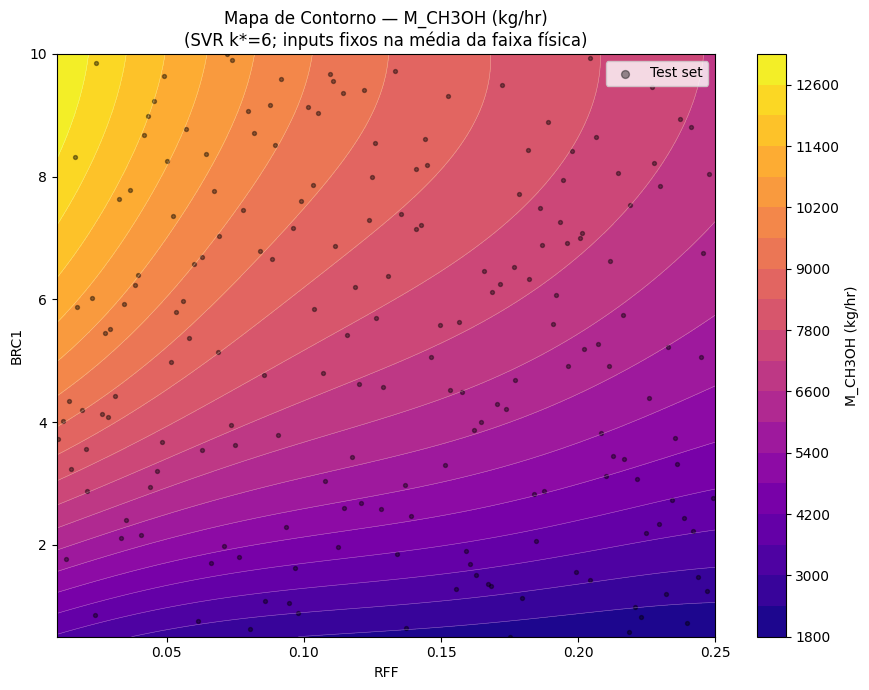

Salvo: 6.1_sr_M_BRC1_RFF_contorno.png


In [7]:
fig, ax = plt.subplots(figsize=(9, 7))

cf = ax.contourf(RFF_mesh, BRC1_mesh, M_pred, levels=20, cmap='plasma')
fig.colorbar(cf, ax=ax, label='M_CH3OH (kg/hr)')
ax.contour(RFF_mesh, BRC1_mesh, M_pred, levels=20, colors='white', linewidths=0.4, alpha=0.4)

ax.scatter(RFF_test, BRC1_test, c='black', s=8, alpha=0.4, label='Test set')

ax.set_xlabel('RFF')
ax.set_ylabel('BRC1')
ax.set_title('Mapa de Contorno — M_CH3OH (kg/hr)\n(SVR k*=6; inputs fixos na média da faixa física)')
ax.legend(loc='upper right', markerscale=2)

plt.tight_layout()
plt.savefig(f"{BASE_OUT}/6.1_sr_M_BRC1_RFF_contorno.png", dpi=150, bbox_inches='tight')
plt.show()
print("Salvo: 6.1_sr_M_BRC1_RFF_contorno.png")


## Seção 5 — Interpretação

### Coerência com os índices de Sobol (Etapa 4)

A Etapa 4 identificou, para **ET**, os seguintes índices de primeira ordem:  
- RFF: S₁ ≈ 0.437 (dominante)  
- BRC1: S₁ ≈ 0.318 (segundo maior)

**Padrão esperado nas superfícies:**  
O gradiente ao longo do eixo RFF (horizontal nos mapas de contorno) deve ser mais acentuado do que ao longo do eixo BRC1 (vertical), refletindo que RFF explica maior fração da variância de ET de forma aditiva. Se as isocurvas de ET forem predominantemente verticais (paralelas ao eixo BRC1), isso indica que RFF é de fato o driver principal, consistente com S₁(RFF) > S₁(BRC1).

Para **M_CH3OH**, os índices Sobol apontam BRC1 e RFF como influentes, mas com pesos relativos distintos dos verificados para ET. Diferenças no padrão das superfícies de ET e M_CH3OH evidenciam que os dois outputs respondem de forma não idêntica ao mesmo par de inputs — o que motiva a otimização multi-objetivo da Etapa 6.3 em vez de otimizar cada output isoladamente.

**Decisão D-E6-03:** o par (RFF, BRC1) foi selecionado com base nos índices S₁ de ET. O mesmo par é usado para M_CH3OH neste notebook para permitir comparação direta das duas superfícies sobre a mesma grade (D-E6-03).

## Seção 6 — Validação

In [8]:
import os

artefatos = [
    "6.1_sr_ET_M_BRC1_RFF_3d.png",
    "6.1_sr_ET_M_BRC1_RFF_contorno.png",
    "6.1_sr_M_BRC1_RFF_3d.png",
    "6.1_sr_M_BRC1_RFF_contorno.png",
]

print("=== Validação 6.1 ===")
for f in artefatos:
    exists = os.path.isfile(f"{BASE_OUT}/{f}")
    print(f"  {'OK' if exists else 'FALTA'} — {f}")

print(f"\nGrid shape  : {X_grid.shape}  (esperado: (40000, 6))")
print(f"NaN ET      : {np.isnan(ET_pred).sum()}  (esperado: 0)")
print(f"NaN M_CH3OH : {np.isnan(M_pred).sum()}  (esperado: 0)")
print(f"Overlay test: {len(X_test_raw)} pontos disponíveis")
print(f"ET  (kW)    : [{ET_pred.min():.0f}, {ET_pred.max():.0f}]")
print(f"M   (kg/hr) : [{M_pred.min():.1f}, {M_pred.max():.1f}]")


=== Validação 6.1 ===
  OK — 6.1_sr_ET_M_BRC1_RFF_3d.png
  OK — 6.1_sr_ET_M_BRC1_RFF_contorno.png
  OK — 6.1_sr_M_BRC1_RFF_3d.png
  OK — 6.1_sr_M_BRC1_RFF_contorno.png

Grid shape  : (40000, 6)  (esperado: (40000, 6))
NaN ET      : 0  (esperado: 0)
NaN M_CH3OH : 0  (esperado: 0)
Overlay test: 193 pontos disponíveis
ET  (kW)    : [8147, 83525]
M   (kg/hr) : [1802.3, 13098.3]
